# SAJU ML Diagnostics V1.1

## tl;dr

The first Career run was promising but too small to promote:

- Production Control macro pairwise: **0.4845**
- Best ML, `B_PLUS_TENGOD_HIDDEN / PairwiseLogit`: **0.5982**
- Control subject hit: **11/23**
- Best ML subject hit: **16/23**

This notebook does **not** add new esoteric features yet.

It asks four cheaper questions first:

1. Does the result survive many different subject-level fold assignments?
2. Is the signal personalized, or can Sewoon/calendar-year features alone explain it?
3. Is the gain really from time-varying Ten-God activation rather than static hidden-stem features?
4. Is the result stronger than a within-subject label-permutation null?

Only after these pass should we add strength, yongshin, 12-unseong, shinsal, etc.

## Context & Methods

### Hard boundaries

- Development-only corpus
- Career only
- No Validation B
- No Public CHECK
- No Public FINAL
- No Cursor / production wiring
- Same subject never appears in train and test
- Pairwise learning uses within-person positive-vs-negative year differences

In [1]:
from pathlib import Path
from itertools import product
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 20260815
N_REPEATS = 50
N_FOLDS = 5
N_PERMUTATIONS = 200
TARGET_DOMAIN = "Career"

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the Chartpalja saju repo.")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "research" / "ml_corpus" / "v1"
ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1_1"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORPUS_PATH = DATA_DIR / "SAJU_ML_CORPUS_V1.json"
FEATURE_PARQUET = REPO_ROOT / "research" / "ml" / "artifacts" / "v1" / "ml_feature_table_v1.parquet"
FEATURE_CSV = REPO_ROOT / "research" / "ml" / "artifacts" / "v1" / "ml_feature_table_v1.csv"

print("repo:", REPO_ROOT)
print("artifacts:", ARTIFACT_DIR)

repo: /Users/sangjinlee/Desktop/projects/saju
artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1_1


## Data

In [2]:
corpus = json.load(open(CORPUS_PATH, encoding="utf-8"))

if FEATURE_PARQUET.exists():
    feature_df = pd.read_parquet(FEATURE_PARQUET)
elif FEATURE_CSV.exists():
    feature_df = pd.read_csv(FEATURE_CSV)
else:
    raise FileNotFoundError(
        "Feature cache not found. Run saju_ml_research_v1.ipynb first."
    )

subject_by_id = {s["subject_id"]: s for s in corpus["subjects"]}

def build_target_rows(domain):
    raw = []
    for s in corpus["subjects"]:
        if not s["birth"]["birth_time_known"]:
            continue
        for e in s["events"]:
            if not e["ml_usable"]:
                continue
            label = e["targets"].get(domain, "unknown")
            if label not in {"positive", "negative"}:
                continue
            raw.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "source_pool": s["source_pool"],
                "year": int(e["year"]),
                "label": 1 if label == "positive" else 0,
                "event_id": e["event_id"],
            })

    raw_df = pd.DataFrame(raw)
    grouped = []
    collisions = []
    for (sid, year), g in raw_df.groupby(["subject_id", "year"]):
        labels = set(g["label"])
        if len(labels) > 1:
            collisions.append((sid, int(year), list(g["event_id"])))
            continue
        grouped.append({
            "subject_id": sid,
            "name": g["name"].iloc[0],
            "source_pool": g["source_pool"].iloc[0],
            "year": int(year),
            "label": int(g["label"].iloc[0]),
        })
    return pd.DataFrame(grouped), collisions

target_rows, collisions = build_target_rows(TARGET_DOMAIN)
model_df = target_rows.merge(
    feature_df, on=["subject_id", "year"], how="inner", validate="one_to_one"
)

pairable_subjects = []
for sid, g in model_df.groupby("subject_id"):
    if set(g["label"]) == {0, 1}:
        pairable_subjects.append(sid)

pair_df = model_df[model_df["subject_id"].isin(pairable_subjects)].copy()

print("Career event-years:", len(model_df))
print("Career subjects:", model_df["subject_id"].nunique())
print("Pair-evaluable subjects:", len(pairable_subjects))
print("Pair-evaluable rows:", len(pair_df))
print("Positive / negative rows:",
      int(pair_df["label"].sum()),
      int((1 - pair_df["label"]).sum()))
print("Colliding subject-years excluded:", len(collisions))

Career event-years: 212
Career subjects: 63
Pair-evaluable subjects: 23
Pair-evaluable rows: 113
Positive / negative rows: 75 38
Colliding subject-years excluded: 2


### Feature sets for diagnosis

The original `B_PLUS_TENGOD_HIDDEN` combines:

- raw natal / Daewoon / Sewoon identity features
- time-varying Daewoon/Sewoon Ten-God groups
- static natal hidden-stem counts

In a within-person **linear pairwise difference**, static natal values cancel exactly.
So this notebook separates the blocks.

In [3]:
basic_cols = [c for c in pair_df.columns if c.startswith("basic__")]
tengod_cols = [c for c in pair_df.columns if c.startswith("tengod__")]
hidden_cols = [c for c in pair_df.columns if c.startswith("hidden__")]
relation_cols = [c for c in pair_df.columns if c.startswith("relation__")]

sw_only_cols = [c for c in basic_cols if c.startswith("basic__sw_")]
dw_sw_raw_cols = [
    c for c in basic_cols
    if c.startswith(("basic__dw_", "basic__sw_"))
]

FEATURE_SETS = {
    "SEWOON_ONLY": sw_only_cols,
    "DW_SW_RAW": dw_sw_raw_cols,
    "TEN_GOD_ONLY": tengod_cols,
    "B_NO_HIDDEN": basic_cols + tengod_cols,
    "B_ORIGINAL": basic_cols + tengod_cols + hidden_cols,
    "C_PLUS_RELATIONS": basic_cols + tengod_cols + hidden_cols + relation_cols,
}

for name, cols in FEATURE_SETS.items():
    print(f"{name:20s} {len(cols):4d} features")

SEWOON_ONLY            29 features
DW_SW_RAW              58 features
TEN_GOD_ONLY           10 features
B_NO_HIDDEN           176 features
B_ORIGINAL            186 features
C_PLUS_RELATIONS      207 features


## Metrics and model

In [4]:
PAIRWISE_LOGIT = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.3,
        max_iter=3000,
        random_state=SEED,
    )),
])

def make_pairwise_training(df, cols):
    Xs, ys = [], []
    for sid, g in df.groupby("subject_id"):
        pos = g[g["label"] == 1]
        neg = g[g["label"] == 0]
        if len(pos) == 0 or len(neg) == 0:
            continue
        for _, p in pos.iterrows():
            for _, n in neg.iterrows():
                diff = p[cols].to_numpy(float) - n[cols].to_numpy(float)
                Xs.append(diff);  ys.append(1)
                Xs.append(-diff); ys.append(0)
    return np.asarray(Xs), np.asarray(ys)

def subject_pairwise_rows(df, score_col):
    rows = []
    for sid, g in df.groupby("subject_id"):
        pos = g.loc[g["label"] == 1, score_col].dropna().to_numpy(float)
        neg = g.loc[g["label"] == 0, score_col].dropna().to_numpy(float)
        if len(pos) == 0 or len(neg) == 0:
            continue
        wins = [
            1.0 if p > n else 0.5 if p == n else 0.0
            for p, n in product(pos, neg)
        ]
        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(wins)),
            "hit": float(np.mean(pos) > np.mean(neg)),
            "sep": float(np.mean(pos) - np.mean(neg)),
        })
    return pd.DataFrame(rows)

def aggregate_subject_metrics(subject_rows):
    return {
        "n_subjects": len(subject_rows),
        "macro_pairwise": float(subject_rows["pairwise"].mean()),
        "subject_hit_rate": float(subject_rows["hit"].mean()),
        "median_sep": float(subject_rows["sep"].median()),
    }

control_subject = subject_pairwise_rows(pair_df, "baseline__control_score")
control_metrics = aggregate_subject_metrics(control_subject)
print(control_metrics)

{'n_subjects': 23, 'macro_pairwise': 0.48454106280193243, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -1.3333333333333428}


## Repeated randomized subject-level CV

The original V1 used one deterministic GroupKFold partition.
Here we repeat randomized subject partitions 50 times.

This is still development diagnostics, not a new holdout.

In [5]:
def subject_folds(subject_ids, n_folds, seed):
    ids = np.array(sorted(subject_ids), dtype=object)
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    return [list(x) for x in np.array_split(ids, n_folds)]

def cv_once(df, cols, seed):
    pred = pd.Series(np.nan, index=df.index, dtype=float)
    folds = subject_folds(df["subject_id"].unique(), N_FOLDS, seed)

    for test_subjects in folds:
        test_mask = df["subject_id"].isin(test_subjects)
        train_mask = ~test_mask
        train_df = df.loc[train_mask]
        test_df = df.loc[test_mask]

        Xp, yp = make_pairwise_training(train_df, cols)
        model = clone(PAIRWISE_LOGIT)
        model.fit(Xp, yp)

        scaler = model.named_steps["scale"]
        clf = model.named_steps["model"]
        Xte = scaler.transform(test_df[cols].to_numpy(float))
        pred.loc[test_df.index] = Xte @ clf.coef_.ravel()

    out = df[["subject_id", "year", "label"]].copy()
    out["score"] = pred
    srows = subject_pairwise_rows(out, "score")
    return aggregate_subject_metrics(srows), srows

repeat_rows = []
first_predictions = {}

for fs_name, cols in FEATURE_SETS.items():
    for repeat in range(N_REPEATS):
        seed = SEED + repeat
        metrics, srows = cv_once(pair_df, cols, seed)
        repeat_rows.append({
            "feature_set": fs_name,
            "repeat": repeat,
            "seed": seed,
            **metrics,
        })
        if repeat == 0:
            first_predictions[fs_name] = srows.copy()

repeat_df = pd.DataFrame(repeat_rows)
summary = repeat_df.groupby("feature_set").agg(
    pairwise_mean=("macro_pairwise", "mean"),
    pairwise_median=("macro_pairwise", "median"),
    pairwise_p10=("macro_pairwise", lambda x: np.quantile(x, 0.10)),
    pairwise_p90=("macro_pairwise", lambda x: np.quantile(x, 0.90)),
    hit_mean=("subject_hit_rate", "mean"),
    hit_p10=("subject_hit_rate", lambda x: np.quantile(x, 0.10)),
    hit_p90=("subject_hit_rate", lambda x: np.quantile(x, 0.90)),
).sort_values("pairwise_mean", ascending=False)

print("CONTROL:", control_metrics)
display(summary)
summary.to_csv(ARTIFACT_DIR / "career_repeated_cv_summary_v1_1.csv")
repeat_df.to_csv(ARTIFACT_DIR / "career_repeated_cv_all_v1_1.csv", index=False)

CONTROL: {'n_subjects': 23, 'macro_pairwise': 0.48454106280193243, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -1.3333333333333428}


,pairwise_mean,pairwise_median,pairwise_p10,pairwise_p90,hit_mean,hit_p10,hit_p90
feature_set,,,,,,,
TEN_GOD_ONLY,0.601916,0.610455,0.558609,0.641580,0.631304,0.565217,0.695652
B_NO_HIDDEN,0.573493,0.575017,0.523958,0.636649,0.642609,0.560870,0.739130
B_ORIGINAL,0.573493,0.575017,0.523958,0.636649,0.642609,0.560870,0.739130
DW_SW_RAW,0.554885,0.552484,0.470842,0.632895,0.587826,0.473913,0.739130
C_PLUS_RELATIONS,0.548502,0.544117,0.480007,0.621605,0.585217,0.521739,0.656522
SEWOON_ONLY,0.547428,0.547671,0.482198,0.610173,0.572174,0.473913,0.652174


## Personalization check

Interpretation:

- If `SEWOON_ONLY` is already as strong as `B_ORIGINAL`, the model may mostly be learning calendar-year patterns rather than a personalized saju relationship.
- If `TEN_GOD_ONLY` or `B_NO_HIDDEN` clearly beats `SEWOON_ONLY`, the signal is more consistent with a personalized Day-Master x luck-stem interaction.
- `B_NO_HIDDEN` and `B_ORIGINAL` should be nearly identical in a linear within-person ranking model because static hidden-stem counts cancel.

In [6]:
comparison = summary.loc[
    [x for x in [
        "SEWOON_ONLY",
        "DW_SW_RAW",
        "TEN_GOD_ONLY",
        "B_NO_HIDDEN",
        "B_ORIGINAL",
        "C_PLUS_RELATIONS",
    ] if x in summary.index]
].copy()

comparison["vs_control"] = comparison["pairwise_mean"] - control_metrics["macro_pairwise"]
comparison["vs_sewoon_only"] = (
    comparison["pairwise_mean"] - summary.loc["SEWOON_ONLY", "pairwise_mean"]
)
display(comparison)
comparison.to_csv(ARTIFACT_DIR / "career_personalization_check_v1_1.csv")

,pairwise_mean,pairwise_median,pairwise_p10,pairwise_p90,hit_mean,hit_p10,hit_p90,vs_control,vs_sewoon_only
feature_set,,,,,,,,,
SEWOON_ONLY,0.547428,0.547671,0.482198,0.610173,0.572174,0.473913,0.652174,0.062887,0.000000
DW_SW_RAW,0.554885,0.552484,0.470842,0.632895,0.587826,0.473913,0.739130,0.070344,0.007458
TEN_GOD_ONLY,0.601916,0.610455,0.558609,0.641580,0.631304,0.565217,0.695652,0.117375,0.054488
B_NO_HIDDEN,0.573493,0.575017,0.523958,0.636649,0.642609,0.560870,0.739130,0.088952,0.026065
B_ORIGINAL,0.573493,0.575017,0.523958,0.636649,0.642609,0.560870,0.739130,0.088952,0.026065
C_PLUS_RELATIONS,0.548502,0.544117,0.480007,0.621605,0.585217,0.521739,0.656522,0.063961,0.001074


## Within-subject label permutation null

This preserves each person's number of positive and negative years, but randomly assigns which years are positive.

A low permutation p-value means the learned ordering is difficult to explain by chance under this development dataset.

In [7]:
B_COLS = FEATURE_SETS["B_NO_HIDDEN"]

observed_metrics, _ = cv_once(pair_df, B_COLS, SEED)
observed = observed_metrics["macro_pairwise"]

rng = np.random.default_rng(SEED + 999)
null_scores = []

for perm in range(N_PERMUTATIONS):
    perm_df = pair_df.copy()
    for sid, idx in perm_df.groupby("subject_id").groups.items():
        idx = list(idx)
        labels = perm_df.loc[idx, "label"].to_numpy().copy()
        rng.shuffle(labels)
        perm_df.loc[idx, "label"] = labels

    m, _ = cv_once(perm_df, B_COLS, SEED)
    null_scores.append(m["macro_pairwise"])

null_scores = np.asarray(null_scores)
perm_p = (1 + np.sum(null_scores >= observed)) / (N_PERMUTATIONS + 1)

print("Observed B_NO_HIDDEN:", observed)
print("Null mean:", float(null_scores.mean()))
print("Permutation p:", float(perm_p))

pd.DataFrame({"null_macro_pairwise": null_scores}).to_csv(
    ARTIFACT_DIR / "career_permutation_null_v1_1.csv", index=False
)

Observed B_NO_HIDDEN: 0.5765010351966874
Null mean: 0.49675086266390617
Permutation p: 0.18407960199004975


## Paired subject bootstrap against Production Control

In [8]:
best_subject = first_predictions["B_NO_HIDDEN"].rename(
    columns={"pairwise": "ml_pairwise", "hit": "ml_hit", "sep": "ml_sep"}
)
ctrl_subject = control_subject.rename(
    columns={"pairwise": "control_pairwise", "hit": "control_hit", "sep": "control_sep"}
)

paired = best_subject.merge(ctrl_subject, on="subject_id", how="inner")
paired["pairwise_delta"] = paired["ml_pairwise"] - paired["control_pairwise"]
paired["hit_delta"] = paired["ml_hit"] - paired["control_hit"]

rng = np.random.default_rng(SEED + 1234)
boot = []
vals = paired["pairwise_delta"].to_numpy(float)
for _ in range(10000):
    sample = rng.choice(vals, size=len(vals), replace=True)
    boot.append(sample.mean())
boot = np.asarray(boot)

print("subjects:", len(paired))
print("Mean paired pairwise delta:", vals.mean())
print("95% bootstrap CI:", np.quantile(boot, [0.025, 0.975]))
print("Bootstrap P(delta > 0):", float(np.mean(boot > 0)))

paired.sort_values("pairwise_delta").to_csv(
    ARTIFACT_DIR / "career_subject_deltas_v1_1.csv", index=False
)
display(paired.sort_values("pairwise_delta"))

subjects: 23
Mean paired pairwise delta: 0.09195997239475501
95% bootstrap CI: [-0.15973257  0.33140097]
Bootstrap P(delta > 0): 0.7716


,subject_id,ml_pairwise,ml_hit,ml_sep,control_pairwise,control_hit,control_sep,pairwise_delta,hit_delta
1,MLV1_FA_006,0.000000,0.0,-2.781886,1.000000,1.0,7.000000,-1.000000,-1.0
2,MLV1_FA_008,0.000000,0.0,-3.052449,1.000000,1.0,2.500000,-1.000000,-1.0
14,MLV1_OLD_023,0.000000,0.0,-2.449377,1.000000,1.0,12.000000,-1.000000,-1.0
8,MLV1_OLD_004,0.000000,0.0,-2.180691,0.666667,1.0,2.000000,-0.666667,-1.0
18,MLV1_PUB_005,0.500000,1.0,1.703109,1.000000,1.0,11.500000,-0.500000,0.0
5,MLV1_FA_012,0.500000,0.0,-0.332507,1.000000,1.0,3.500000,-0.500000,-1.0
11,MLV1_OLD_015,0.142857,0.0,-1.852246,0.500000,1.0,0.428571,-0.357143,-1.0
0,MLV1_FA_002,0.500000,1.0,0.642318,0.500000,1.0,0.500000,0.000000,0.0
22,MLV1_PUB_022,0.500000,1.0,0.477436,0.500000,0.0,-2.000000,0.000000,1.0
6,MLV1_OLD_001,0.600000,1.0,1.202479,0.450000,1.0,0.600000,0.150000,0.0


## Results plots

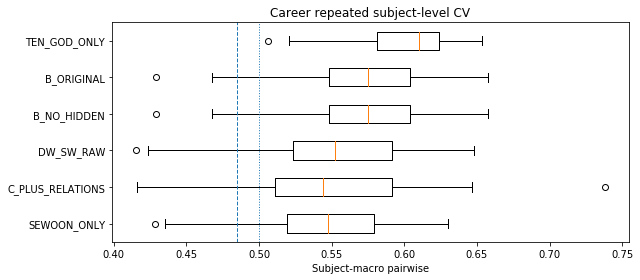

In [10]:
order = summary.sort_values("pairwise_mean").index.tolist()

data = [
    repeat_df.loc[
        repeat_df["feature_set"] == x,
        "macro_pairwise"
    ].to_numpy()
    for x in order
]

fig, ax = plt.subplots(figsize=(9, max(4, len(order) * 0.65)))

ax.boxplot(
    data,
    vert=False,
    labels=order
)

ax.axvline(
    control_metrics["macro_pairwise"],
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0.5,
    linestyle=":",
    linewidth=1
)

ax.set_xlabel("Subject-macro pairwise")
ax.set_title("Career repeated subject-level CV")

plt.tight_layout()
plt.show()

## Takeaways and next decision

### Move to Feature V2 only if the pattern is broadly like this

- `B_NO_HIDDEN` repeated-CV mean remains materially above Production Control
- lower-tail performance is not collapsing below chance
- `B_NO_HIDDEN` clearly beats `SEWOON_ONLY`
- `TEN_GOD_ONLY` contributes meaningful signal
- permutation result is comfortably stronger than chance
- paired subject bootstrap is mostly positive rather than being driven by 2-3 people

### If that passes

Build `saju_ml_research_v2.ipynb` and add feature blocks **one at a time**:

1. strength / seasonal strength
2. yongshin, heeshin, gishin activation
3. johou / structure
4. 12-unseong
5. shinsal / lucky stars last

Keep a block only if repeated out-of-subject CV improves.

### If it fails

Do not tune model coefficients.
Improve Career labels/corpus first, then rerun the same V1.1 diagnostics.